Analise completa de portfolio

PARKING LOT:

_ Adicionar a estatística descritiva dos dados iniciais, para verificar como é o comportamento de cada um e comparar entre eles.

_ Adicionar a média dos valores de rentabilidade de cada ativo, já que a volatilidade é um desvio-padrão em 
relação à média.

_ Criar um índice de sortino com a diferença (Retorno Mínimo Aceitável, RMA) em relação a zero, e não contra o CDI.

_ Criar o índice de sortino ajustado, conforme metodologia de cálculo do livro.

_ Criar o indicador Ganho x Perda, baseado na soma de todos os retornos mensais dividida pelo valor absoluto da
soma  de todos os prejuízos mensais.

_ Criar gráficos de valores consolidados de cada ativo.

_ Comparar os indicadores em diferentes janelas de tempo. Entender quais janelas de tempo fazem sentido.

In [1]:
# ==============================================================================
# CÉLULA 1: IMPORTAÇÕES E CONFIGURAÇÃO INICIAL
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import yfinance as yf
import datetime
from scipy import stats

# Configuração Visual
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("tab10")

# --- FUNÇÕES DE SUPORTE ---

def parse_pt_date(date_str):
    """Converte datas em português (ex: 'jan-22') para datetime."""
    month_map = {
        'janeiro': 1, 'fevereiro': 2, 'março': 3, 'abril': 4, 'maio': 5, 'junho': 6,
        'julho': 7, 'agosto': 8, 'setembro': 9, 'outubro': 10, 'novembro': 11, 'dezembro': 12,
        'jan': 1, 'fev': 2, 'mar': 3, 'abr': 4, 'mai': 5, 'jun': 6,
        'jul': 7, 'ago': 8, 'set': 9, 'out': 10, 'nov': 11, 'dez': 12
    }
    try:
        if isinstance(date_str, (pd.Timestamp, datetime.datetime)): return date_str # verifica se 
        # a variável date_str já é do tipo pd.Timestamp OU do tipo datetime.datetime.
        # Caso seja, a função retorna a própria variável date_str sem realizar nenhuma conversão adicional. 
        # Isso é útil para evitar erros de conversão quando a data já está no formato correto.
        parts = str(date_str).split('-')
        # if len(parts) != 2: return pd.NaT # comentado para ficar mais robusto a formatos variados
        month_name = parts[0].lower().strip()
        year_full = 2000 + int(parts[1])
        return pd.Timestamp(year=year_full, month=month_map.get(month_name, 1), day=1) + pd.offsets.MonthEnd(0)
    except:
        # return pd.NaT # comentado para ficar mais robusto a formatos variados
        raise ValueError("VERIFICAR FORMATO DA DATA: " + str(date_str))

def get_cdi_local(file_path, start_date, end_date):
    """Lê o CDI de arquivo Excel local."""
    print(f"Lendo CDI local: {file_path}...")
    try:
        cdi = pd.read_excel(file_path)
        cdi.columns.values[0] = 'data_raw'
        cdi.columns.values[1] = 'valor'
        
        def parse_ipea_date(val):
            # Se for float, força 2 casas decimais (ex: 2022.1 -> "2022.10")
            if isinstance(val, (float, int)):
                val_str = f"{val:.2f}"
            else:
                val_str = str(val).strip()

            if '.' in val_str:
                parts = val_str.split('.')
                year = int(parts[0])
                month = int(parts[1])
                return pd.Timestamp(year=year, month=month, day=1) + pd.offsets.MonthEnd(0)
        
            return pd.to_datetime(val) + pd.offsets.MonthEnd(0)

        cdi['data'] = cdi['data_raw'].apply(parse_ipea_date)
        cdi = cdi.dropna(subset=['data']).set_index('data').sort_index()
        
        if cdi['valor'].dtype == object:
            cdi['valor'] = cdi['valor'].astype(str).str.replace(',', '.').astype(float)
            
        mask = (cdi.index >= pd.to_datetime(start_date)) & (cdi.index <= pd.to_datetime(end_date))
        cdi = cdi.loc[mask]
        cdi['monthly_decimal'] = cdi['valor'] / 100
        # return cdi['monthly_decimal'].resample('ME').last()
        return cdi['monthly_decimal'].resample('ME').apply(lambda x: np.prod(1+x)-1) # para calcular o >
        # > CDI mensal composto corretamente, mesmo quando há mais de um valor por mês.
    except Exception as e:
        print(f"ERRO ao ler CDI: {e}")
        return None

In [2]:
# ==============================================================================
# CÉLULA 2: CLASSES E MÉTODOS PARA MANIPULAÇÃO DE DADOS E CÁLCULO DE MÉTRICAS
# ==============================================================================

import pandas as pd
import numpy as np
from typing import Tuple, List, Optional

class PortfolioMetrics:
    """
    Calculates quantitative KPIs for a dataframe containing monthly asset returns.
    The class is designed to be flexible and reusable, allowing for easy extension with additional metrics if needed.
    """
    def __init__(self, returns_df: pd.DataFrame, risk_free_col: str = 'CDI', market_col: str = 'Global_BRL'):
        # Data is safely anchored to the object
        self.returns = returns_df
        self.rf_col = risk_free_col
        self.mkt_col = market_col
        
        # Identify all assets to be analyzed
        self.assets: List[str] = self.returns.columns.tolist()
        
        # Financial periods parameter (monthly data = 12 periods per year)
        self.periods_per_year = 12
        self.total_years = len(self.returns) / self.periods_per_year
        
        # Pre-calculate the Risk-Free CAGR since it acts as the MAR (Minimum Acceptable Return)
        # using the exact compounding logic from the original notebook
        rf_total_ret = (1 + self.returns[self.rf_col]).prod() - 1
        self.rf_cagr = (1 + rf_total_ret) ** (1 / self.total_years) - 1

    def calc_cagr(self, ticker: str) -> float:
        """Calculates the Compound Annual Growth Rate using monthly returns."""
        total_ret = (1 + self.returns[ticker]).prod() - 1
        return (1 + total_ret) ** (1 / self.total_years) - 1

    def calc_volatility(self, ticker: str) -> float:
        """Calculates annualized volatility assuming homoscedasticity."""
        return self.returns[ticker].std() * np.sqrt(self.periods_per_year)

    def calc_max_drawdown(self, ticker: str) -> float:
        """Calculates the absolute maximum drawdown from the equity curve."""
        wealth = (1 + self.returns[ticker]).cumprod()
        drawdown = (wealth - wealth.cummax()) / wealth.cummax()
        return drawdown.min()

    def calc_sharpe(self, ticker: str) -> float:
        """Calculates the annualized Sharpe Ratio against the defined risk-free rate."""
        if ticker == self.rf_col:
            return 0.0
            
        excess_ret = self.returns[ticker] - self.returns[self.rf_col]
        if excess_ret.std() == 0:
            return 0.0
            
        return (excess_ret.mean() / excess_ret.std()) * np.sqrt(self.periods_per_year)

    def calc_sortino(self, ticker: str) -> float:
        """
        Calculates the Adjusted Sortino Ratio.
        Instead of filtering strictly < 0, it penalizes returns below the risk-free rate (MAR).
        """
        cagr = self.calc_cagr(ticker)
        
        # Calculate excess returns relative to the monthly Risk-Free rate
        excess = self.returns[ticker] - self.returns[self.rf_col]
        
        # Isolate downside risk using numpy (values below MAR)
        downside = np.where(excess < 0, excess, 0)
        downside_vol = np.sqrt(np.mean(downside**2)) * np.sqrt(self.periods_per_year)
        
        if downside_vol == 0:
            return 0.0
            
        return (cagr - self.rf_cagr) / downside_vol

    def calc_beta_alpha(self, ticker: str) -> Tuple[float, float]:
        """
        Calculates Beta and Annualized Alpha using Covariance/Variance.
        Returns a Tuple containing (Beta, Alpha).
        """
        if ticker == self.rf_col:
            return 0.0, 0.0
            
        excess_asset = self.returns[ticker] - self.returns[self.rf_col]
        excess_mkt = self.returns[self.mkt_col] - self.returns[self.rf_col]
        
        # Align data dropping NaNs
        df = pd.concat([excess_asset, excess_mkt], axis=1).dropna()
        df.columns = ['y', 'x']
        
        variance = df['x'].var()
        if len(df) < 6 or variance == 0:
            return np.nan, np.nan
            
        covariance = df.cov().iloc[0, 1]
        beta = covariance / variance
        
        # Alpha calculation
        alpha_monthly = df['y'].mean() - beta * df['x'].mean()
        alpha_annual = ((1 + alpha_monthly) ** self.periods_per_year) - 1
        
        return beta, alpha_annual

    def calc_calmar(self, ticker: str) -> float:
        """Calculates the Calmar Ratio."""
        cagr = self.calc_cagr(ticker)
        max_dd = self.calc_max_drawdown(ticker)
        
        if max_dd == 0:
            return 0.0
            
        return cagr / abs(max_dd)
    
    def calc_rolling_sharpe(self, ticker: str, window: int = 36) -> pd.Series:
        """
        Calcula a série temporal do Índice de Sharpe rolante.
        O padrão é uma janela de 36 meses (3 anos).
        """
        if ticker == self.rf_col:
            return pd.Series(0.0, index=self.returns.index)
            
        excess_ret = self.returns[ticker] - self.returns[self.rf_col]
        
        # Utilização do método .rolling() do Pandas de forma vetorizada
        rolling_mean = excess_ret.rolling(window=window).mean()
        rolling_std = excess_ret.rolling(window=window).std()
        
        # Previne divisão por zero
        rolling_std = rolling_std.replace(0, np.nan)
        
        rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(self.periods_per_year)
        return rolling_sharpe.dropna()

    def calc_rolling_beta(self, ticker: str, window: int = 36) -> pd.Series:
        """
        Calcula a série temporal do Beta rolante contra o mercado.
        """
        if ticker == self.rf_col:
            return pd.Series(0.0, index=self.returns.index)
            
        excess_asset = self.returns[ticker] - self.returns[self.rf_col]
        excess_mkt = self.returns[self.mkt_col] - self.returns[self.rf_col]
        
        # Variância rolante do mercado e Covariância rolante
        rolling_var_mkt = excess_mkt.rolling(window=window).var()
        rolling_cov = excess_asset.rolling(window=window).cov(excess_mkt)
        
        rolling_beta = rolling_cov / rolling_var_mkt
        return rolling_beta.dropna()

    def calc_equity_curve(self, ticker: str) -> pd.Series:
        """
        Calculates the cumulative wealth (equity curve) of an asset assuming 
        an initial investment of 1.0 (base 100%).
        """
        # We use cumprod to compound the monthly returns
        wealth = (1 + self.returns[ticker]).cumprod()
        # Normalize to start at 1.0
        wealth.iloc[0] = 1.0 
        return wealth

    def calc_underwater_curve(self, ticker: str) -> pd.Series:
        """
        Calculates the underwater curve (drawdown series) over time.
        It shows the percentage drop from the historical peak at each point in time.
        """
        wealth = self.calc_equity_curve(ticker)
        previous_peaks = wealth.cummax()
        drawdowns = (wealth - previous_peaks) / previous_peaks
        return drawdowns

    def calc_cvar(self, ticker: str, confidence_level: float = 0.05) -> float:
        """
        Calculates the Conditional Value at Risk (CVaR) / Expected Shortfall.
        It represents the average loss in the worst (confidence_level)% of cases.
        """
        returns = self.returns[ticker].dropna()
        
        # Find the Value at Risk (VaR) threshold (the 5th percentile)
        var_threshold = np.percentile(returns, confidence_level * 100)
        
        # Calculate the average of returns that are worse than the VaR threshold
        cvar = returns[returns <= var_threshold].mean()
        
        return cvar

    def calc_win_loss_ratio(self, ticker: str) -> float:
        """
        Calculates the Win/Loss Ratio.
        Formula: Average of positive monthly returns / Absolute average of negative monthly returns.
        """
        returns = self.returns[ticker].dropna()
        
        positive_returns = returns[returns > 0]
        negative_returns = returns[returns < 0]
        
        # Prevent division by zero
        if len(negative_returns) == 0 or negative_returns.mean() == 0:
            return np.nan
            
        avg_win = positive_returns.mean()
        avg_loss = abs(negative_returns.mean())
        
        return avg_win / avg_loss

    def generate_descriptive_stats(self) -> pd.DataFrame:
        """
        Generates a robust statistical summary of the monthly returns.
        Includes Annualized Mean to match the temporal scale of Annualized Volatility.
        """
        stats_df = self.returns.describe().T
        
        # Add shape metrics
        stats_df['skewness'] = self.returns.skew()
        stats_df['kurtosis'] = self.returns.kurtosis()
        
        # Add Annualized Mean (Arithmetic) for direct volatility comparison
        # Formula: (1 + monthly_mean)^12 - 1
        monthly_mean = stats_df['mean']
        stats_df['annualized_mean'] = (1 + monthly_mean)**self.periods_per_year - 1
        
        # Reorder columns for better readability
        cols = ['annualized_mean', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'skewness', 'kurtosis']
        return stats_df[cols]

    def generate_metrics_table(self) -> pd.DataFrame:
        """
        Orchestrates all calculations and returns a consolidated DataFrame,
        now including Tail Risk (CVaR) and Asymmetry (Win/Loss).
        """
        results = []
        for asset in self.assets:
            beta, alpha = self.calc_beta_alpha(asset)
            
            results.append({
                'Ativo': asset,
                'CAGR': self.calc_cagr(asset),
                'Vol': self.calc_volatility(asset),
                'Sharpe': self.calc_sharpe(asset),
                'Sortino': self.calc_sortino(asset),
                'Calmar': self.calc_calmar(asset),
                'MaxDD': self.calc_max_drawdown(asset),
                'CVaR (95%)': self.calc_cvar(asset, confidence_level=0.05),
                'Win/Loss': self.calc_win_loss_ratio(asset),
                'Alpha (vs Global)': alpha,
                'Beta (vs Global)': beta
            })
            
        df_metrics = pd.DataFrame(results).set_index('Ativo')
        return df_metrics

In [3]:
# ==============================================================================
# CÉLULA 3: CARREGAMENTO E CONSOLIDAÇÃO (COM VT TOTAL RETURN)
# ==============================================================================

from pathlib import Path # Importação necessária para lidar com caminhos

# --- DEFINIÇÃO ROBUSTA DE CAMINHOS (NOVA ESTRUTURA DE PASTAS) ---
# 1. Identifica onde este notebook está rodando (na pasta 'notebooks')
CWD = Path.cwd()

# 2. Define a raiz do projeto (uma pasta acima da atual)
# O atributo .parent sobe um nível na hierarquia
PROJECT_ROOT = CWD.parent

# 3. Define o caminho da pasta de dados
DATA_DIR = PROJECT_ROOT / 'data'

# 4. Define os caminhos completos para os arquivos Excel
# O operador '/' funciona para unir caminhos no Windows, Mac e Linux automaticamente
FILE_PORTFOLIO = DATA_DIR / 'dados.xlsx'
FILE_CDI = DATA_DIR / 'dados_cdi.xlsx'

# Verificação de segurança (opcional, mas recomendada)
print(f"Buscando dados em: {DATA_DIR}")
if not FILE_PORTFOLIO.exists():
    raise FileNotFoundError(f"ERRO CRÍTICO: O arquivo {FILE_PORTFOLIO.name} não foi encontrado na pasta /data.")

# Parâmetros de Datas
START_DATE = '2010-01-01'
END_DATE = datetime.datetime.now().strftime('%Y-%m-%d')

print("--- INICIANDO CARGA DE DADOS ---")

# 1. Carregar Carteira
try:
    df_port = pd.read_excel(FILE_PORTFOLIO)
    df_port['Date'] = df_port['Data'].apply(parse_pt_date)
    df_port = df_port.dropna(subset=['Date']).set_index('Date').sort_index()
    
    col_ret = 'Rentabilidade até a Data'
    if df_port[col_ret].dtype == 'object':
        port_ret = df_port[col_ret].astype(str).str.replace('%','').str.replace(',','.').astype(float)/100
    else:
        port_ret = df_port[col_ret]
    
    port_ret = port_ret.resample('ME').last()
    
except Exception as e:
    print(f"Erro Carteira: {e}")
    port_ret = pd.Series(dtype=float)

# 2. Carregar CDI
cdi_ret = get_cdi_local(FILE_CDI, START_DATE, END_DATE)
if cdi_ret is None: 
    print("AVISO: Criando CDI zerado.")
    cdi_ret = pd.Series(0.0, index=port_ret.index)

# 3. Baixar Benchmarks Globais (VT = Vanguard Total World)
# Utilizado VT no lugar do S&P 500 puro para ser alinhado com alocação global
tickers = ['VT', 'BRL=X', '^BVSP'] 
print(f"Baixando benchmarks (VT Global, Ibov, Dólar): {tickers}...")

try:
    # Baixamos explicitamente 'Adj Close' para capturar DIVIDENDOS (Acumulação)
    dl = yf.download(tickers, start=START_DATE, end=END_DATE, interval='1mo', progress=False)
    
    # Tratamento para diferentes versões do yfinance (MultiIndex ou não)
    if isinstance(dl.columns, pd.MultiIndex):
        # Se tiver MultiIndex, pegamos Adj Close explicitamente se disponível, 
        # senão Close (que costuma ser ajustado por padrão no Yahoo)
        try:
            mkt = dl['Adj Close']
        except KeyError:
            mkt = dl['Close']
            print("Aviso: Usando 'Close'. Verifique se 'auto_adjust' foi aplicado.")
    else:
        mkt = dl
        
    mkt = mkt.ffill()
    
    # Criar VT em BRL (Global Total Return em Reais)
    # VT (USD) * Taxa de Câmbio
    mkt['VT_BRL'] = mkt['VT'] * mkt['BRL=X']
    
    # Calcular Retornos Mensais
    bench_global = mkt['VT_BRL'].pct_change().resample('ME').last()
    bench_ibov = mkt['^BVSP'].pct_change().resample('ME').last()
    
except Exception as e:
    print(f"Erro Yahoo: {e}")
    bench_global = pd.Series(dtype=float)
    bench_ibov = pd.Series(dtype=float)

# 4. Consolidar e ALINHAR
dfs = [port_ret, cdi_ret, bench_global, bench_ibov]
comp_df = pd.concat(dfs, axis=1)
comp_df.columns = ['Portfolio', 'CDI', 'Global_BRL', 'Ibovespa']

# Alinhamento
comp_df = comp_df.dropna()

print(f"Dados Consolidados! Período: {comp_df.index[0].date()} a {comp_df.index[-1].date()}")

comp_df

Buscando dados em: c:\Projetos_Python\kpis_carteira\data
--- INICIANDO CARGA DE DADOS ---
Lendo CDI local: c:\Projetos_Python\kpis_carteira\data\dados_cdi.xlsx...
Baixando benchmarks (VT Global, Ibov, Dólar): ['VT', 'BRL=X', '^BVSP']...
YF.download() has changed argument auto_adjust default to True
Aviso: Usando 'Close'. Verifique se 'auto_adjust' foi aplicado.
Dados Consolidados! Período: 2011-01-31 a 2026-01-31


,Portfolio,CDI,Global_BRL,Ibovespa
2011-01-31,-0.013531,0.0086,0.016460,-0.039391
2011-02-28,0.012608,0.0084,0.045482,0.012137
2011-03-31,0.031074,0.0092,-0.019566,0.017868
2011-04-30,-0.021506,0.0084,0.016481,-0.035779
2011-05-31,-0.012199,0.0099,-0.018552,-0.022878
...,...,...,...,...
2025-09-30,0.011465,0.0122,0.010064,0.034047
2025-10-31,0.043128,0.0128,0.035400,0.022587
2025-11-30,-0.000385,0.0105,-0.002819,0.063742
2025-12-31,0.050389,0.0122,0.023791,0.012906


In [4]:
# ==============================================================================
# CÉLULA 4: EXECUÇÃO PRINCIPAL PARA GERAR E EXIBIR A TABELA DE MÉTRICAS
# ==============================================================================

# 1. Instantiate the object, injecting the 'comp_df' dataframe generated in Cell 3
analyzer = PortfolioMetrics(returns_df=comp_df, risk_free_col='CDI', market_col='Global_BRL')

# 2. Request the object to generate the complete table at once
metrics_table = analyzer.generate_metrics_table()

# 3. Display using your specific formatting and color gradient pattern
print("=== TABELA DE PERFORMANCE CONSOLIDADA (BENCHMARK: VT GLOBAL) ===")
display(metrics_table.style.format({
    'CAGR': '{:.2%}', 'Vol': '{:.2%}', 'MaxDD': '{:.2%}', 'Alpha (vs Global)': '{:.2%}',
    'Sharpe': '{:.2f}', 'Sortino': '{:.2f}', 'Calmar': '{:.2f}', 'Beta (vs Global)': '{:.2f}'
}).background_gradient(cmap='RdYlGn', subset=['CAGR', 'Sharpe', 'Alpha (vs Global)']))

=== TABELA DE PERFORMANCE CONSOLIDADA (BENCHMARK: VT GLOBAL) ===


,CAGR,Vol,Sharpe,Sortino,Calmar,MaxDD,CVaR (95%),Win/Loss,Alpha (vs Global),Beta (vs Global)
Ativo,,,,,,,,,,
Portfolio,10.44%,10.11%,0.11,0.10,0.47,-22.34%,-0.058095,1.405585,-0.58%,0.19
CDI,9.72%,1.00%,0.00,0.00,0.00,0.00%,0.001709,nan,0.00%,0.00
Global_BRL,18.85%,15.47%,0.59,0.96,0.67,-28.21%,-0.074760,1.405437,0.00%,1.00
Ibovespa,6.59%,21.12%,-0.03,-0.20,0.16,-41.09%,-0.124282,1.105026,0.32%,-0.10


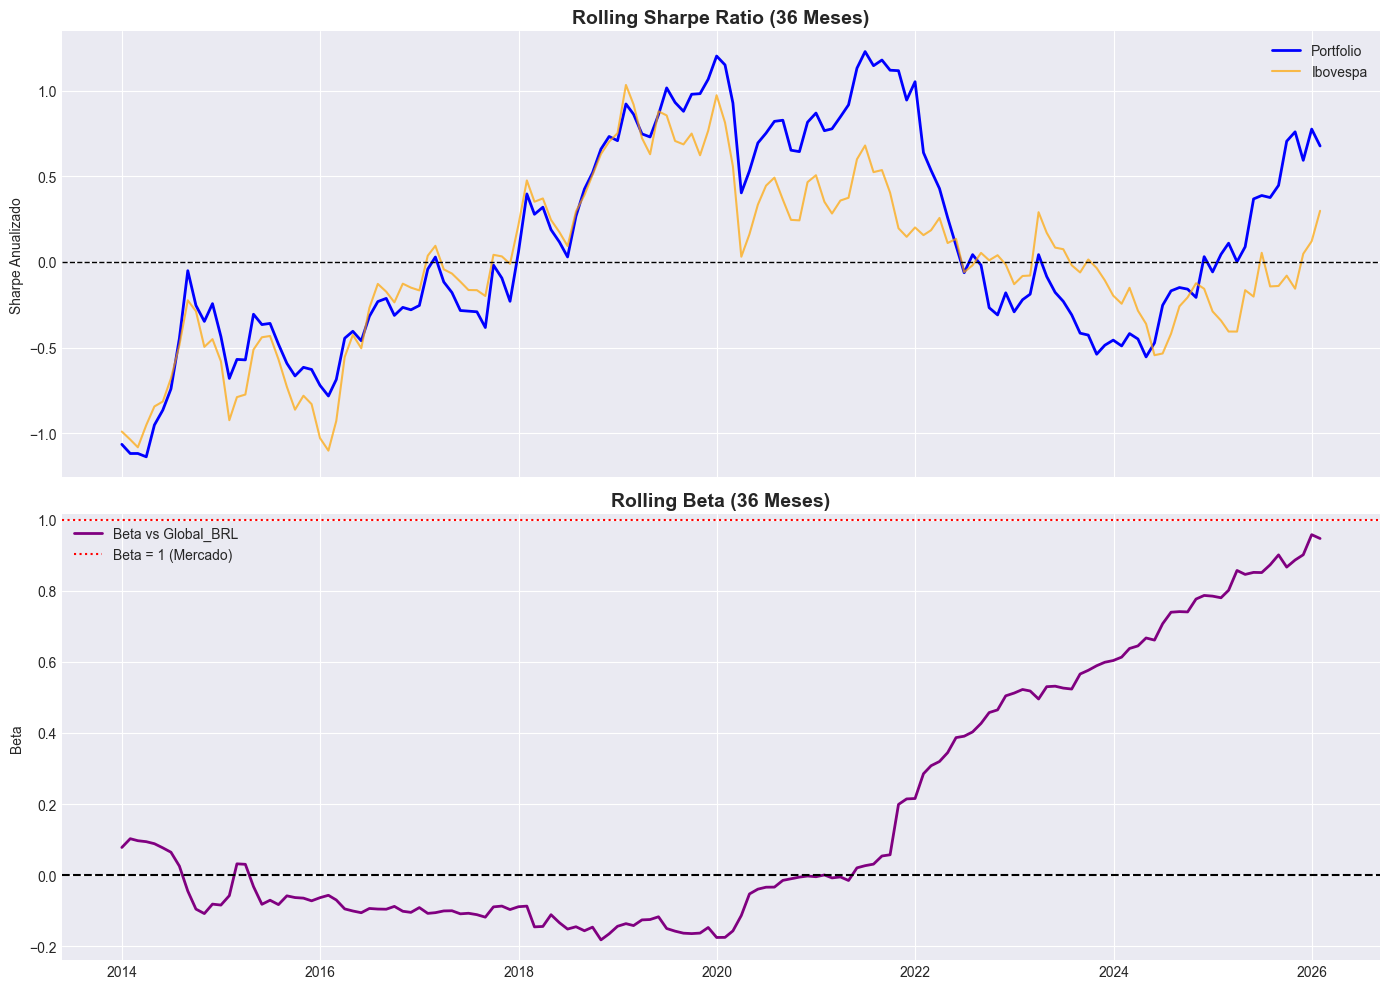

In [5]:
# ==========================================
# CÉLULA 5: VISUALIZAÇÃO DE MÉTRICAS ROLANTES
# ==========================================
import matplotlib.pyplot as plt

# Definimos uma janela de 3 anos (36 meses)
janela = 36

# 1. Pedimos ao nosso 'analyzer' as séries temporais rolantes do Portfolio
rolling_sharpe_port = analyzer.calc_rolling_sharpe('Portfolio', window=janela)
rolling_beta_port = analyzer.calc_rolling_beta('Portfolio', window=janela)

# 2. Pedimos as do Ibovespa para comparar
rolling_sharpe_ibov = analyzer.calc_rolling_sharpe('Ibovespa', window=janela)

# 3. Construção do Tear Sheet Visual
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Gráfico 1: Sharpe Rolante
ax1.plot(rolling_sharpe_port.index, rolling_sharpe_port, label='Portfolio', color='blue', linewidth=2)
ax1.plot(rolling_sharpe_ibov.index, rolling_sharpe_ibov, label='Ibovespa', color='orange', alpha=0.7)
ax1.axhline(0, color='black', linestyle='--', linewidth=1)
ax1.set_title(f'Rolling Sharpe Ratio ({janela} Meses)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Sharpe Anualizado')
ax1.legend()

# Gráfico 2: Beta Rolante
ax2.plot(rolling_beta_port.index, rolling_beta_port, label=f'Beta vs {analyzer.mkt_col}', color='purple', linewidth=2)
ax2.axhline(1, color='red', linestyle=':', label='Beta = 1 (Mercado)')
ax2.axhline(0, color='black', linestyle='--')
ax2.set_title(f'Rolling Beta ({janela} Meses)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Beta')
ax2.legend()

plt.tight_layout()
plt.show()

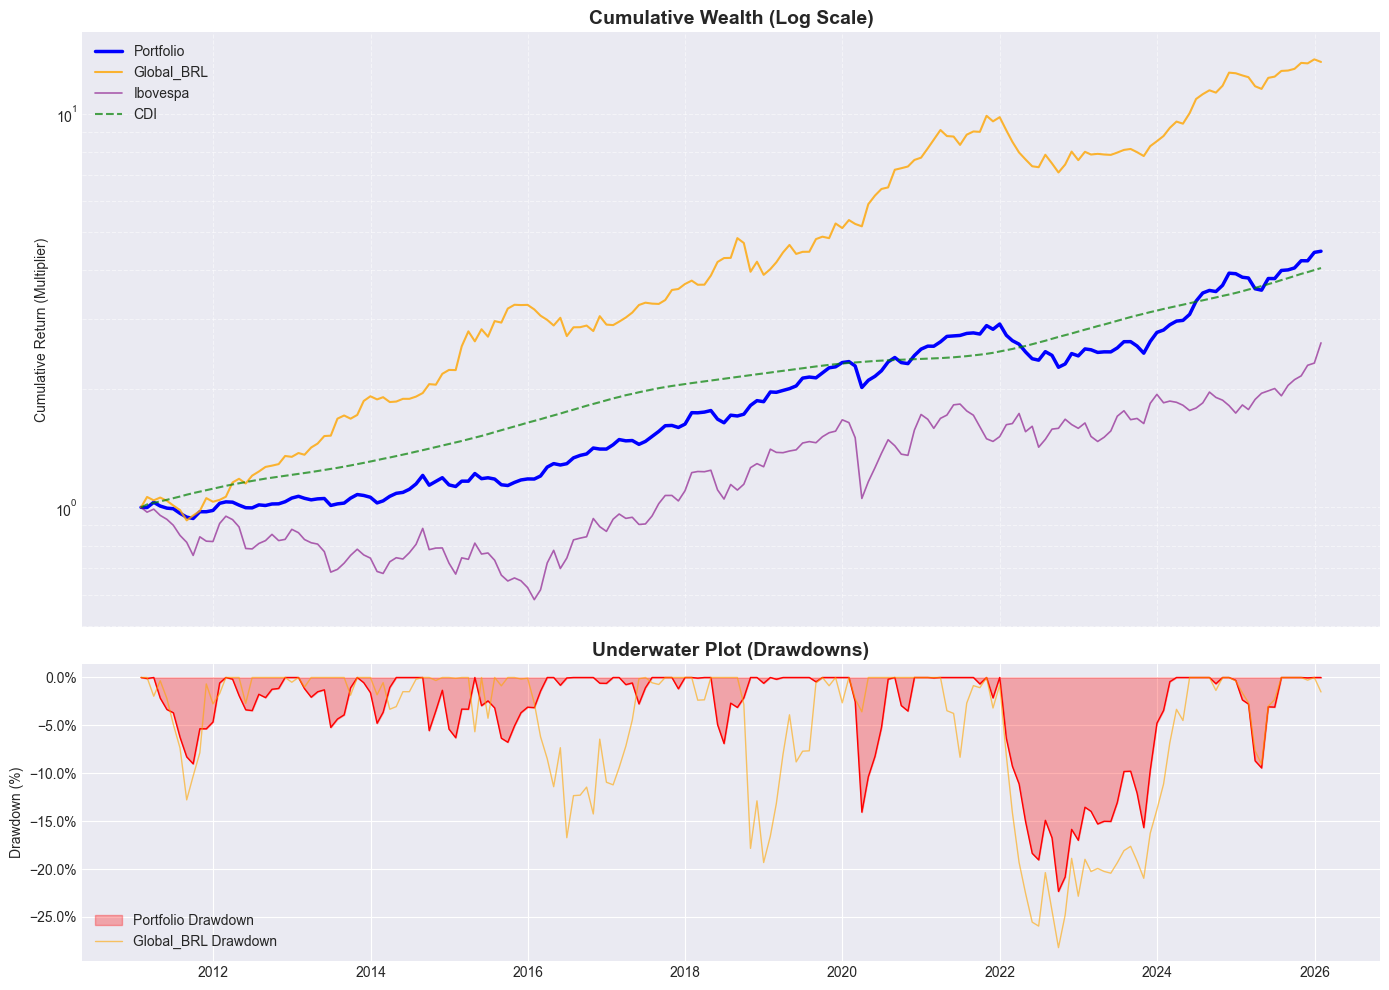

In [6]:
# ==========================================
# CELL 6: EQUITY CURVE & UNDERWATER PLOT
# ==========================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# 1. Fetch the data
portfolio_equity = analyzer.calc_equity_curve('Portfolio')
global_equity = analyzer.calc_equity_curve(analyzer.mkt_col)
cdi_equity = analyzer.calc_equity_curve('CDI')
ibov_equity = analyzer.calc_equity_curve('Ibovespa') # <-- Added Ibovespa

portfolio_dd = analyzer.calc_underwater_curve('Portfolio')
global_dd = analyzer.calc_underwater_curve(analyzer.mkt_col)

# 2. Build the visual
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

# --- Top Chart: Cumulative Returns ---
ax1.plot(portfolio_equity.index, portfolio_equity, label='Portfolio', color='blue', linewidth=2.5)
ax1.plot(global_equity.index, global_equity, label=f'{analyzer.mkt_col}', color='orange', alpha=0.8, linewidth=1.5)
ax1.plot(ibov_equity.index, ibov_equity, label='Ibovespa', color='purple', alpha=0.6, linewidth=1.2) # <-- Added Ibovespa
ax1.plot(cdi_equity.index, cdi_equity, label='CDI', color='green', linestyle='--', alpha=0.7)

ax1.set_title('Cumulative Wealth (Log Scale)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Cumulative Return (Multiplier)')
ax1.set_yscale('log') 
ax1.legend(loc='upper left')
ax1.grid(True, which="both", ls="--", alpha=0.5)

# --- Bottom Chart: Underwater Plot ---
ax2.fill_between(portfolio_dd.index, portfolio_dd, 0, color='red', alpha=0.3, label='Portfolio Drawdown')
ax2.plot(portfolio_dd.index, portfolio_dd, color='red', linewidth=1)
ax2.plot(global_dd.index, global_dd, color='orange', alpha=0.6, linewidth=1, label=f'{analyzer.mkt_col} Drawdown')

ax2.set_title('Underwater Plot (Drawdowns)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Drawdown (%)')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.legend(loc='lower left')

plt.tight_layout()
plt.show()

In [7]:
# ==========================================
# CELL 7: DESCRIPTIVE STATISTICS
# ==========================================

# 1. Ask the object to generate the descriptive statistics dataframe
desc_stats = analyzer.generate_descriptive_stats()

print("=== MONTHLY RETURNS: DESCRIPTIVE STATISTICS & DISTRIBUTION SHAPE ===")

# 2. Display with conditional formatting to highlight non-normal distributions
display(desc_stats.style.format({
    'annualized_mean': '{:.2%}', 'mean': '{:.2%}', 'std': '{:.2%}', 'min': '{:.2%}', 
    '25%': '{:.2%}', '50%': '{:.2%}', '75%': '{:.2%}', 'max': '{:.2%}',
    'skewness': '{:.2f}', 'kurtosis': '{:.2f}'
}).background_gradient(
    cmap='coolwarm', subset=['skewness', 'kurtosis']
))

=== MONTHLY RETURNS: DESCRIPTIVE STATISTICS & DISTRIBUTION SHAPE ===


,annualized_mean,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Portfolio,11.00%,0.87%,2.92%,-11.83%,-0.65%,0.67%,2.89%,8.05%,-0.45,1.62
CDI,9.73%,0.78%,0.29%,0.13%,0.54%,0.83%,1.02%,1.28%,-0.47,-0.67
Global_BRL,20.23%,1.55%,4.46%,-15.47%,-1.27%,1.36%,4.50%,14.90%,0.00,0.99
Ibovespa,9.02%,0.72%,6.10%,-29.90%,-3.12%,0.70%,4.69%,16.97%,-0.50,2.80


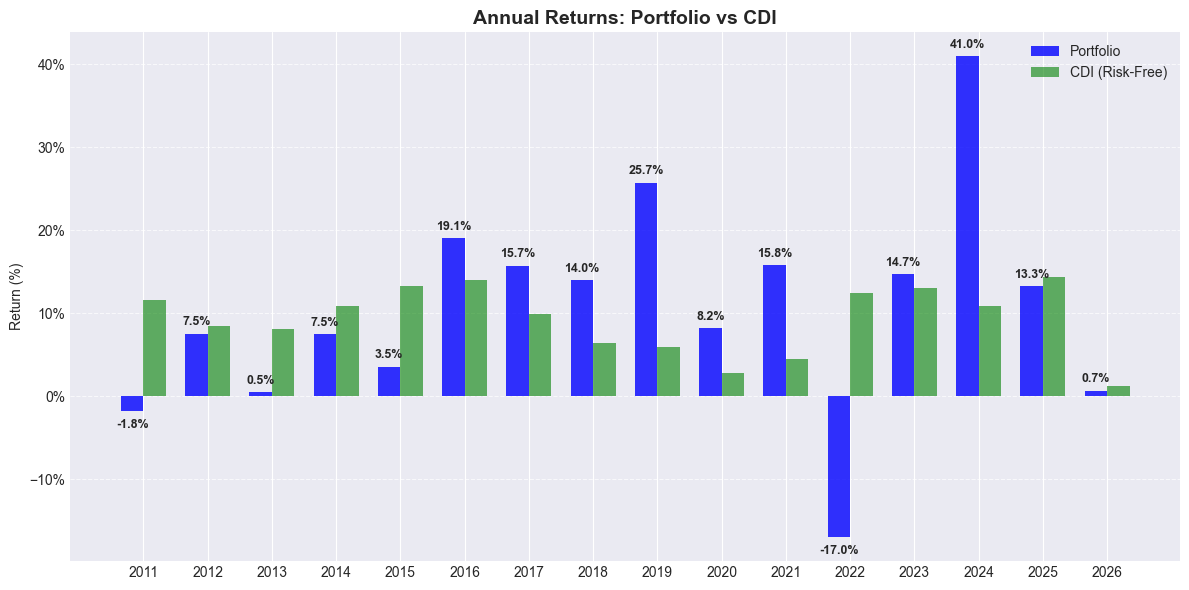

In [8]:
# ==========================================
# CELL 8: ANNUAL RETURNS BAR CHART
# ==========================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# 1. Resample monthly returns to annual returns geometrically
annual_returns = (1 + analyzer.returns).resample('YE').prod() - 1
# Extract just the year for the X-axis labels
annual_returns.index = annual_returns.index.year 

# 2. Plotting the Bar Chart
fig, ax = plt.subplots(figsize=(12, 6))

width = 0.35
x = annual_returns.index

# Plot Portfolio and CDI side-by-side
ax.bar(x - width/2, annual_returns['Portfolio'], width, label='Portfolio', color='blue', alpha=0.8)
ax.bar(x + width/2, annual_returns['CDI'], width, label='CDI (Risk-Free)', color='green', alpha=0.6)

ax.set_title('Annual Returns: Portfolio vs CDI', fontsize=14, fontweight='bold')
ax.set_ylabel('Return (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xticks(x)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentage text above/below the bars for the Portfolio
for i, v in enumerate(annual_returns['Portfolio']):
    y_pos = v + 0.01 if v > 0 else v - 0.02
    ax.text(x[i] - width/2, y_pos, f'{v:.1%}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()